# riverWQ EDA — Predicting E. coli Contamination in NZ Rivers

## Project Introduction

This notebook covers the exploratory data analysis required before the final modelling begins. The findings and conclusions will be used for preprocessing and modelling in '02_modelling.ipyb'.

# 1. Setup & Data Loading

## 1.1 Library Import

I will import the following libraries for EDA.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding tool
from sklearn.preprocessing import LabelEncoder
# Scaler tool
from sklearn.preprocessing import StandardScaler
# Data split tool
from sklearn.model_selection import train_test_split
# LogisticRegression method tool
from sklearn.linear_model import LogisticRegression
# KNN model method tool
from sklearn.neighbors import KNeighborsClassifier
# Random Forest method tool
from sklearn.ensemble import RandomForestClassifier
# Classification report tool
from sklearn.metrics import classification_report
# Confusion metrix tool
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## 1.2 Dataset Loading 

In the following code cell, main dataset will be loaded.

In [ ]:
# Load the main dataset
df = pd.read_csv('../data/riverWQ_dataset.csv')


# 2. Initial Profiling

In this section, basic knowledge of the dataset will be worked out. And the quality and potential problems of the dataset will be monitored.

## 2.1 Dataset preview

In the following code cell, the basic information and overlook of dataset will be applied.

In [ ]:
# Show the shape of the dataset
print(f'Dataset shape: {df.shape}')
# Show the first 5 rows
df.head().T

## 2.2 Data types 

In this section, data types of the dataset will be shown to monitor the potential mismatch problems.

In [61]:
# Show the dtype of each column
df.dtypes

site_id                                            str
region                                             str
catchment                                          str
latitude                                       float64
longitude                                      float64
wfs_land_cover                                     str
wfs_altitude                                       str
rec_land_cover_type                                str
mean_annual_rainfall_mm                          int64
pct_cropland                                   float64
pct_forest                                     float64
pct_grassland_other_herbaceous_vegetation      float64
pct_scrub_shrubland                            float64
pct_urban_bare_lightly-vegetated_surfaces      float64
pct_cropping_horticulture                      float64
pct_exotic_forest                              float64
pct_exotic_grassland                           float64
pct_exotic_scrub_shrubland                     float64
pct_indige

**Data type observations**

All dtypes are stored properly, and no conversions are needed at this stage.

## 2.3 Missing value observation

In this section, missing values will be observed in the dataset.

In [30]:
df.isnull().sum()

site_id                                          0
region                                           0
catchment                                        0
latitude                                         0
longitude                                        0
wfs_land_cover                                   0
wfs_altitude                                     0
rec_land_cover_type                              0
mean_annual_rainfall_mm                          0
pct_cropland                                     0
pct_forest                                       0
pct_grassland_other_herbaceous_vegetation        0
pct_scrub_shrubland                              0
pct_urban_bare_lightly-vegetated_surfaces        0
pct_cropping_horticulture                        0
pct_exotic_forest                                0
pct_exotic_grassland                             0
pct_exotic_scrub_shrubland                       0
pct_indigenous_forest                            0
pct_indigenous_scrub_shrubland 

**Missing value findings**

13 columns have missing values and most of them show up in pairs('band' and 'median') apart from 'nitrate_band':

- 1. Target variables:
'ecolin_median' and 'ecoli_band' are both target variables, and each of them have 57 missing values. These rows can't be used for training or evaluation. Since they are target variables, further actions will be needed and discussed.

- 2. Other columns:
Other columns that have missing values such as 'no3n_band' and so on represent water quality outcomes measured alongside E. coli, so they will be excluded later from modelling to avoid data leakage. Thus, no more actions are needed.

## 2.4 Duplicates

In this section, I will check whether the duplicates exist in the dataset.

In [29]:
# Count exact duplicate rows
df.duplicated().sum()

np.int64(0)

**Observations**

There are no duplicates being observed in the dataset.

## 2.5 Implausible values

In this section, numerical values will be checked through to identify any implausible values or unusual values.

In [34]:
# Summary statistics for all numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,396.0,-40.749636,3.028036,-46.515137,-43.205942,-39.794082,-38.400809,-36.344941
longitude,396.0,173.810139,2.858883,167.686111,170.999559,174.995460,175.771552,178.427553
mean_annual_rainfall_mm,396.0,1486.785354,596.707801,542.000000,1092.000000,1413.000000,1677.250000,3373.000000
pct_cropland,396.0,1.475682,4.309309,0.000000,0.060000,0.520000,0.990000,34.740000
pct_forest,396.0,30.286111,20.895960,0.000000,14.040000,32.680000,41.012500,87.260000
pct_grassland_other_herbaceous_vegetation,396.0,53.139470,23.823439,0.000000,36.140000,54.570000,77.900000,93.550000
pct_scrub_shrubland,396.0,6.752121,6.250243,0.000000,3.600000,4.830000,8.490000,52.560000
pct_urban_bare_lightly-vegetated_surfaces,396.0,6.395101,14.950721,0.000000,1.260000,2.290000,3.890000,100.000000
pct_cropping_horticulture,396.0,1.475682,4.309309,0.000000,0.060000,0.520000,0.990000,34.740000
pct_exotic_forest,396.0,9.260631,7.952776,0.000000,3.062500,7.345000,14.700000,44.330000


In [36]:
# Verify the two columns are truly identical
(df['pct_cropland'] == df['pct_cropping_horticulture']).all()

np.True_

**Observations**

No implausible or impossible values are identified across all attributes in the dataset.

While 'pct_cropland' and 'pct_cropping_horticulture' have identical summary statistics (same mean, std, min, max). And verification confirms that they contain identical values. This finding needs discussing furtherly later on.

# 3. Univariate Analysis

This section works out the distribution of each feature and both target variables. The findings in this section will inform preprocessing and modelling decisions.

Two targets variables will be conducted first, followed by numerical and categorical features.

Some attributes should be excluded from univariate analysis.

'site_id' and 'catchment' are identifiers that can be excluded. 

Other water quality attributes such as 'drp_median', 'clarity_median', 'ammoniacal_n_median', 'no3n_median', 'ton_median' and their band will be excluded of analysis here since they do not represent catchment-level characteristics. And the project aims to assess how well catchment-level data can explain E. coli contamination.

'latitude' and 'longitude' will also not be analysed here since they are just geographical features.

## 3.1 Target variables: 'ecoli_median' and 'ecoli_band'

The two target variables are the most important variables in this dataset. So in the following section, statistics, visualisations and analysis on each target variable will be conducted.

### 3.1.1 'ecoli_median'(Regression target)

Its distribution, tendency and shape will be examined for analysis and discussion.

**The statistics will be conducted first**

In [41]:
# Statistics for ecoli_median 
print('=== ecolin_median statistics ===')
print(df['ecoli_median'].describe())

# Skewness and kurtosis
print(f"Skewness: {df['ecoli_median'].skew():.3f}")
print(f"Kurtosis: {df['ecoli_median'].kurtosis():.3f}")

=== ecolin_median statistics ===
count     339.000000
mean      266.066667
std       399.569441
min         1.000000
25%        45.000000
50%       125.000000
75%       290.500000
max      2700.000000
Name: ecoli_median, dtype: float64
Skewness: 3.046
Kurtosis: 11.168


**Statisitcs interpretation**

Skewness is 3.046 which indicates an extreme right skew. And the kurtosis is 11.168 which means it has a long heavy tail. The maximum number also reflects this. The shape shows that most rivers have moderate E. coli while a small group produce extreme high contamination.

This distribution indicates that log transformation will be needed for modelling.

**Visualisations are below**

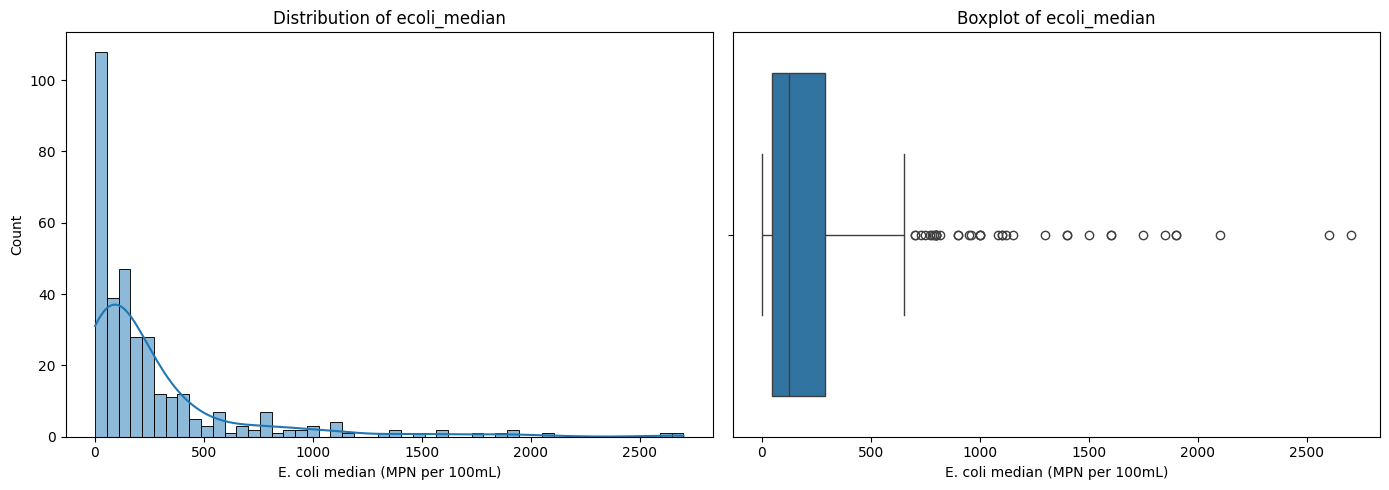

In [ ]:
# Create a fig and axes
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Use seaborn to draw histplots
sns.histplot(df['ecoli_median'].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of ecoli_median')
axes[0].set_xlabel('E. coli median (MPN per 100mL)')
# Use seaborn to draw boxplots
sns.boxplot(x=df['ecoli_median'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot of ecoli_median')
axes[1].set_xlabel('E. coli median (MPN per 100mL)')
# Save the plots itto figures
plt.tight_layout()
plt.savefig('../figures/01_ecoli_median_raw.png', bbox_inches='tight')
plt.show()

**Visualisation findings**

From the histplot, it is clear that most data clustered at low values with a long tail extedning to around 2700 MPN/100ml, which matches the finding in statistics.

Log transformation should be needed for regression and the "outliers" in the boxplots should be the high-contamination situation but the data errors.

**Will try to conduct log transformation to the dataset and see how visualisation looks**

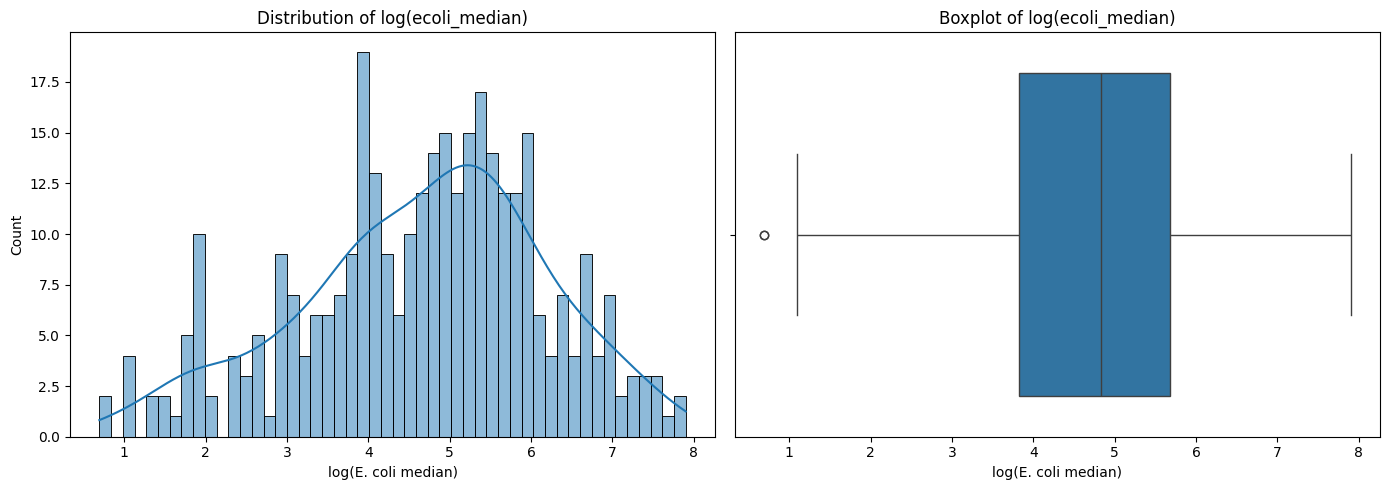

Skewness after log transformation: -0.369


In [53]:
# Temporary log transformation for visualisation only
log_ecoli = np.log1p(df['ecoli_median'].dropna())
# Create a fig and axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Use seaborn to draw histplots
sns.histplot(log_ecoli, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of log(ecoli_median)')
axes[0].set_xlabel('log(E. coli median)')
# Use seaborn to draw boxplots
sns.boxplot(x=log_ecoli, ax=axes[1])
axes[1].set_title('Boxplot of log(ecoli_median)')
axes[1].set_xlabel('log(E. coli median)')
# Save plots into figures
plt.tight_layout()
plt.savefig('../figures/02_ecoli_median_log.png', bbox_inches='tight')
plt.show()
# Skewness after transformation
print(f"Skewness after log transformation: {log_ecoli.skew():.3f}")

**Findings after the log transformation**

After the log transformation, the distribution is approximatel symmetric as is shown above. And skewness dropped from 3.046 to near 0. Thus, the log transformation is effective and the regression target will be modelled after log transformation.

### 3.1.2 'ecoli_band'(Classification target)

'ecoli_band' is a attribute band derived from 'ecoli_median' using fixed thresholds. The class distribution will be examined first.

**Frequency and percentage table will be calculated first**

In [ ]:
# Frequency and percentage of each band
band_counts = df['ecoli_band'].value_counts().sort_index()
band_pct = df['ecoli_band'].value_counts(normalize=True).sort_index() * 100

# Combine into a clean table
band_summary = pd.DataFrame({
    'Count': band_counts,
    'Percentage': band_pct.round(1)
})
print(band_summary)

            Count  Percentage
ecoli_band                   
A              81        23.9
B              33         9.7
C              20         5.9
D             104        30.7
E             101        29.8


**A bar chart will be drawn below to show the visualisation.**

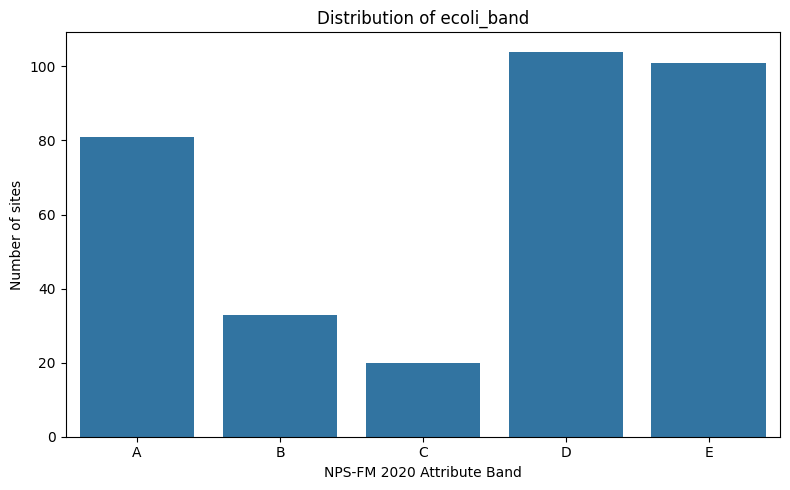

In [60]:
# Create a fig and set the size
plt.figure(figsize=(8, 5))
sns.countplot(x=df['ecoli_band'], order=['A', 'B', 'C', 'D', 'E'])

# Title and axis labels
plt.title('Distribution of ecoli_band')
plt.xlabel('NPS-FM 2020 Attribute Band')
plt.ylabel('Number of sites')

# Save figure
plt.tight_layout()
plt.savefig('../figures/03_ecoli_band_distribution.png', bbox_inches='tight')
plt.show()

**Findings**

The distribution is nearly bimodal. Sites cluster at the both ends of the scale. While the band C is the rarest, which accounts for 5.9%. 

Thus, a moderate class imbalance can be seen. C band should be considered using balancing before modelling for training.

## 3.2 Numerical features

There are 17 numerical features(16 'pct_' and 'mean_annual_rainfall_mm'). All the numerical features will firstly be scanned in one plot, then a few of them will be selected for a more detailed modelling.

**A list will be created which contains all the numerical features with 'pct_', making it easier for the following actions and codes.

In [62]:
# Pick all columns that start with "pct_"
pct_cols = [c for c in df.columns if c.startswith('pct_')]

# Add rainfall to make the full list of numerical features
numerical_features = pct_cols + ['mean_annual_rainfall_mm']

print(numerical_features)

['pct_cropland', 'pct_forest', 'pct_grassland_other_herbaceous_vegetation', 'pct_scrub_shrubland', 'pct_urban_bare_lightly-vegetated_surfaces', 'pct_cropping_horticulture', 'pct_exotic_forest', 'pct_exotic_grassland', 'pct_exotic_scrub_shrubland', 'pct_indigenous_forest', 'pct_indigenous_scrub_shrubland', 'pct_tussock_grassland', 'pct_urban_area', 'pct_other_herbaceous_vegetation', 'pct_natural_bare_lightly-vegetated_surfaces', 'pct_artificial_bare_surfaces', 'mean_annual_rainfall_mm']


### 3.2.1 Distribution overview

A big plot showing the histogram of all 17 numerical features at once, which will provide a quick view of overall looks and shapes.

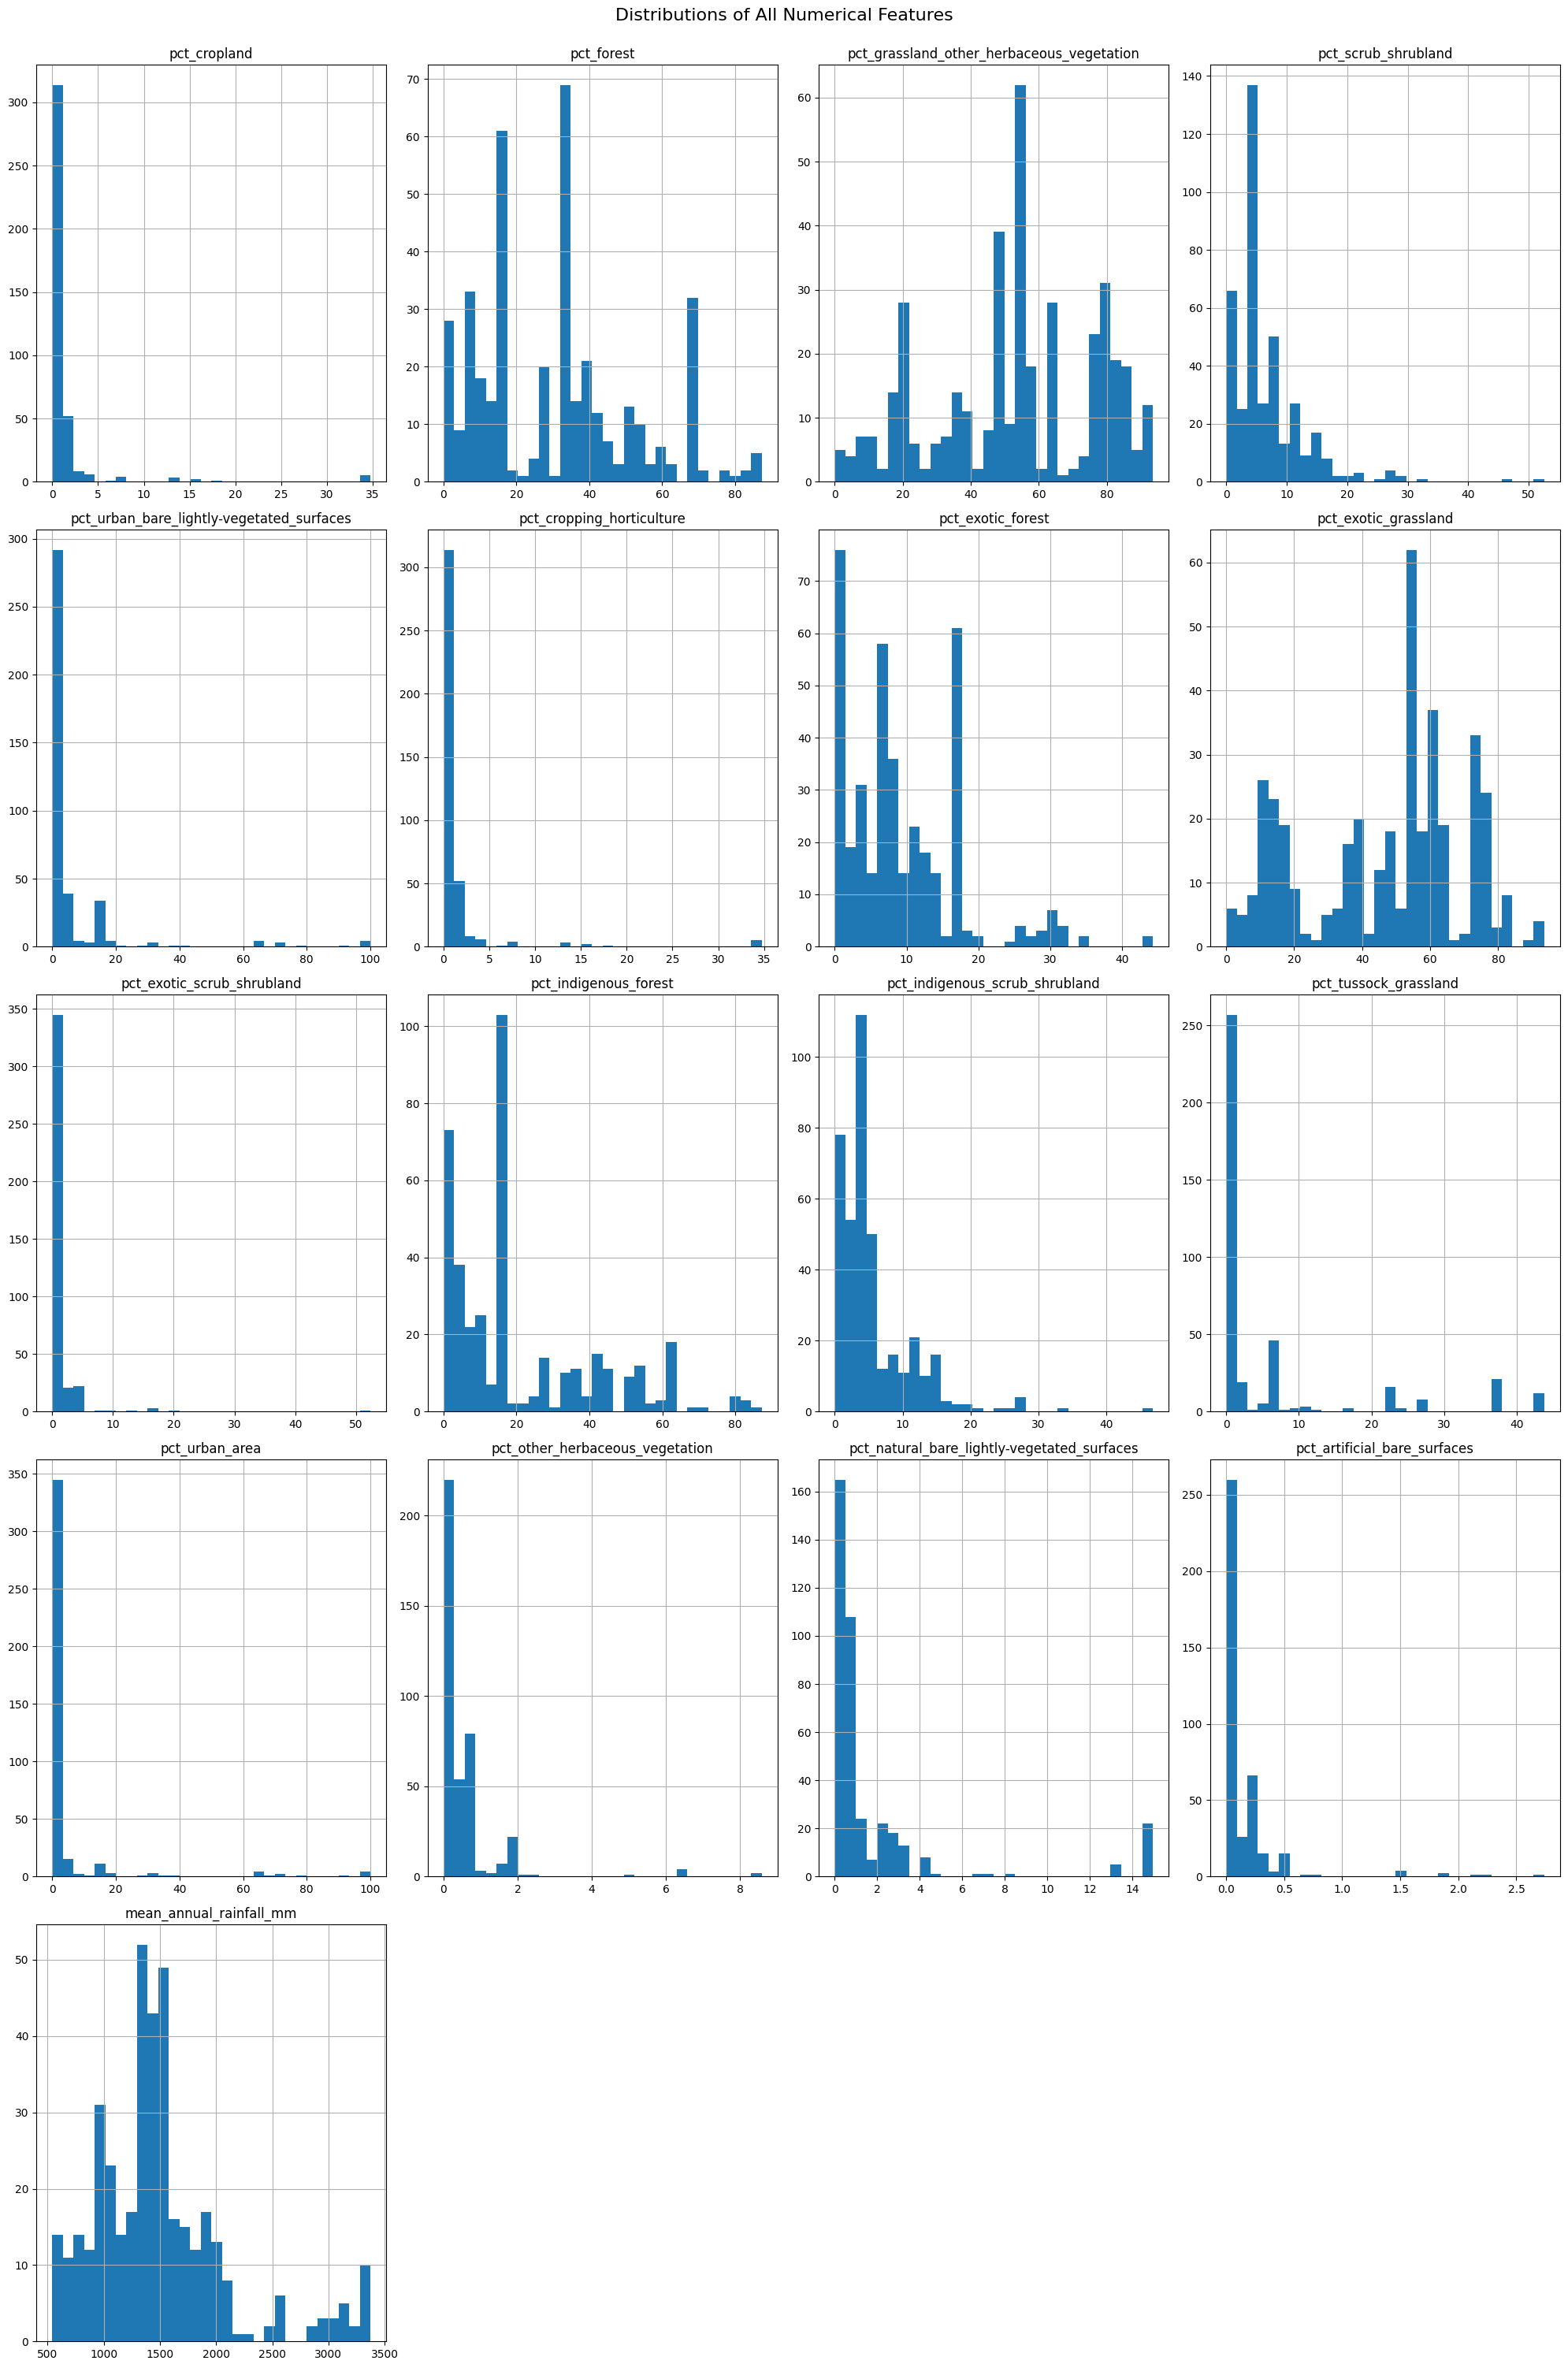

In [70]:
# Plot histograms for all 17 numerical features in one grid
df[numerical_features].hist(figsize=(20, 30), bins=30)

# Add an overall title
plt.suptitle('Distributions of All Numerical Features', fontsize=16, y=1.00)

plt.tight_layout()
plt.savefig('../figures/04_numerical_distributions_grid.png', bbox_inches='tight')
plt.show()

**Initial observations(based on the histogram)**

Over half of the 17 numerical features are right-skewed with many zeros. And a few features appear bimodal or multimodal ('pct_forest', 'pct_exotic_grassland' 'pct_grassland_other_herbaceous_vegetation', 'pct_exotic_forest') 

### 3.2.2 Statistics

To quantify the visual patterns observed in 3.2.1, we compute two key statistics for each numerical feature: skewness (shape) and the proportion of zero values (how often the feature is absent).

In [ ]:
# Calculate skewness and zero proportion for each numerical feature
skew_table = pd.DataFrame({
    'skewness': df[numerical_features].skew().round(2),
    'zero_pct': (df[numerical_features] == 0).mean().round(3) * 100
})

# Sort by skewness
skew_table = skew_table.sort_values('skewness', ascending=False)
skew_table

,skewness,zero_pct
pct_exotic_scrub_shrubland,10.84,4.3
pct_cropland,6.39,15.2
pct_cropping_horticulture,6.39,15.2
pct_other_herbaceous_vegetation,5.34,10.1
pct_artificial_bare_surfaces,5.34,18.4
pct_urban_area,4.81,5.8
pct_urban_bare_lightly-vegetated_surfaces,4.49,0.3
pct_natural_bare_lightly-vegetated_surfaces,2.95,14.4
pct_scrub_shrubland,2.75,1.3
pct_indigenous_scrub_shrubland,2.60,1.8
